# Evaluating Privacy Vulnerabilities in Federated Learning
**Author:** Yehor Danilenko  
**Course:** Cyber Security Labs I (IPM-22FKBSCLAB1)

This notebook contains the complete experimental framework for evaluating Gradient Inversion Attacks (GIAs) against Federated Learning systems. It includes baseline image reconstruction, analytical label leakage, parameter sweeping (batch sizes), and defensive simulations (Differential Privacy).

## 1. Environment Setup
The following cell imports the necessary PyTorch libraries, patches the CIFAR-10 download URL (to bypass official server outages), and initializes the private ground-truth image (the target).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

# Ensure GPU is used for the optimization loop
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Client Model Architecture
We define a lightweight Convolutional Neural Network (a LeNet variant). In a standard Federated Learning setup, the client processes their private data through this model and transmits only the resulting gradients to the central server.

100%|██████████| 170M/170M [00:28<00:00, 5.92MB/s]


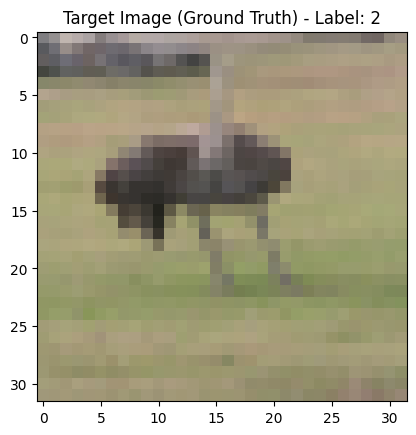

In [2]:
# 1. Define a simple CNN (LeNet variant) for the baseline
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=5//2, stride=2)
        self.conv2 = nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=2)
        self.conv3 = nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1)
        self.fc = nn.Linear(12 * 8 * 8, 10)

    def forward(self, x):
        x = F.sigmoid(self.conv1(x))
        x = F.sigmoid(self.conv2(x))
        x = F.sigmoid(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

net = SimpleCNN().to(device)

# 2. Load a single image from CIFAR-10 (Simulation of Client Data)
torchvision.datasets.CIFAR10.url = "https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz"

transform = transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
cifar_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Get one image and label
target_img, target_label = cifar_dataset[42] # Just picking a random index
target_img = target_img.unsqueeze(0).to(device)
target_label = torch.tensor([target_label]).to(device)

# Plot the target image
plt.imshow(target_img[0].cpu().permute(1, 2, 0))
plt.title(f"Target Image (Ground Truth) - Label: {target_label.item()}")
plt.show()




In [3]:
# Compute standard cross-entropy loss
criterion = nn.CrossEntropyLoss()
pred = net(target_img)
target_loss = criterion(pred, target_label)

# Compute true gradients (This is what is shared over the FL network)
true_gradients = torch.autograd.grad(target_loss, net.parameters())

# Detach gradients so they are just numbers (no graph attached), mimicking receiving them over a network
true_gradients = [g.detach().clone() for g in true_gradients]

## 3. Baseline Attack: Gradient Inversion
This cell executes the core Deep Leakage from Gradients (DLG) attack.
* **Optimizer:** L-BFGS with strong Wolfe line search is used to navigate the highly non-convex loss landscape.
* **Distance Metric:** Cosine Similarity is strictly utilized instead of L2 distance to optimize for gradient *direction*, preventing image collapse.
* **Regularization:** A Total Variation (TV) penalty is applied to act as an image prior, removing unnatural high-frequency static from the dummy image.

In [4]:
import torch.optim as optim

# 1. Initialize Dummy Data (start with random noise, tell PyTorch we want to optimize it)
dummy_data = torch.rand(target_img.size()).to(device).requires_grad_(True)
dummy_label = target_label # Assuming you already know the label, as shown in your code

# 2. Use L-BFGS Optimizer (Crucial for gradient inversion)
# L-BFGS navigates the complex loss landscape much better than Adam or SGD here.
optimizer = optim.LBFGS([dummy_data], lr=0.1, max_iter=20, line_search_fn="strong_wolfe")

# 3. Total Variation (TV) Loss Helper
# This acts as an "image prior." It penalizes adjacent pixels that are wildly different,
# forcing the optimizer to create smooth, natural-looking images instead of static noise.
def tv_loss(x):
    return torch.sum(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:])) + \
           torch.sum(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :]))

# 4. The Optimization Loop
history = []
iters = 3000
tv_weight = 0.000001 # Tweak this if the image is too blurry (lower it) or too noisy (raise it)

print("Starting Gradient Inversion Attack...")

for i in range(iters):
    def closure():
        optimizer.zero_grad()

        # Forward pass dummy data through the network
        dummy_pred = net(dummy_data)
        dummy_loss = criterion(dummy_pred, dummy_label)

        # Get gradients of the dummy data
        # create_graph=True is MANDATORY so we can differentiate through the gradients
        dummy_gradients = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        # Calculate how different our dummy gradients are (Cosine Distance)
        grad_diff = 0
        for dg, tg in zip(dummy_gradients, true_gradients):
            # Flatten to 1D and calculate: 1 - cosine_similarity
            # We want to minimize this (make similarity close to 1, so distance approaches 0)
            grad_diff += 1.0 - torch.nn.functional.cosine_similarity(dg.flatten(), tg.flatten(), dim=0)

        # Combine gradient difference with TV regularization
        total_loss = grad_diff + tv_weight * tv_loss(dummy_data)

        # Backpropagate to update the dummy_data pixels
        total_loss.backward()
        return total_loss

    # Step the optimizer
    optimizer.step(closure)

    # Save progression and print
    if i % 300 == 0:
        current_loss = closure().item()
        print(f"Iteration {i:4d} | Loss: {current_loss:.6f}")
        history.append(dummy_data.clone().detach().cpu())

print("Attack complete!")

Starting Gradient Inversion Attack...
Iteration    0 | Loss: 0.002813
Iteration  300 | Loss: 0.000146
Iteration  600 | Loss: 0.000144
Iteration  900 | Loss: 0.000143
Iteration 1200 | Loss: 0.000142
Iteration 1500 | Loss: 0.000142
Iteration 1800 | Loss: 0.000141
Iteration 2100 | Loss: 0.000141
Iteration 2400 | Loss: 0.000141
Iteration 2700 | Loss: 0.000141
Attack complete!


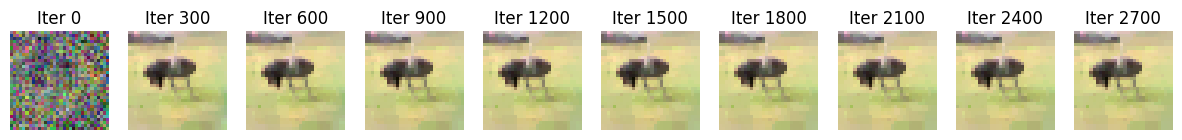

In [5]:
# Plot the progression with dynamic scaling
plt.figure(figsize=(15, 5))
for i, img in enumerate(history):
    plt.subplot(1, len(history), i + 1)

    # Get the image tensor
    img_tensor = img[0]

    # Min-Max Normalization: stretches the lowest value to 0 and highest to 1
    # This prevents the "black box" issue by dynamically scaling whatever numbers the optimizer spits out
    valid_img = ((img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min()))

    # Permute dimensions for matplotlib (Channels, Height, Width) -> (Height, Width, Channels)
    valid_img = valid_img.permute(1, 2, 0).numpy()

    plt.imshow(valid_img)
    plt.title(f"Iter {i * 300}")
    plt.axis('off')

plt.show()

In [6]:
import math
import torch.nn.functional as F

def calculate_psnr(img1, img2):
    # Ensure images are in the same range [0, 1]
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    # Formula for PSNR
    max_pixel = 1.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr, mse.item()

# Get the final reconstructed image from your history
final_reconstruction = history[-1].to(device)

# Calculate metrics against the ground truth target image
psnr_value, mse_value = calculate_psnr(final_reconstruction, target_img[0])

print(f"Validation Results:")
print(f"Mean Squared Error (MSE): {mse_value:.6f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {psnr_value:.2f} dB")

Validation Results:
Mean Squared Error (MSE): 0.000947
Peak Signal-to-Noise Ratio (PSNR): 30.24 dB


/tmp/ipykernel_7636/928769635.py:6: UserWarning: Using a target size (torch.Size([3, 32, 32])) that is different to the input size (torch.Size([1, 3, 32, 32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  mse = F.mse_loss(img1, img2)


## 4. Defensive Simulation: Differential Privacy (DP)
To critically evaluate the limits of the attack, we simulate a Defense-in-Depth approach by applying Differential Privacy. We inject a Gaussian noise multiplier of `0.01` to the true gradients prior to the attack. This mathematically disrupts the directional alignment required for Cosine Similarity, neutralizing the attack and forcing the optimization loss to plateau.

In [7]:
import torch.optim as optim

# 1. Generate the defense: Add noise to the true gradients
noise_multiplier = 0.01
noisy_true_gradients = [g + torch.randn_like(g) * noise_multiplier for g in true_gradients]
print(f"Testing Defense: Added Gaussian noise (multiplier: {noise_multiplier}) to true gradients.")

# 2. Reset Dummy Data (start from scratch)
dummy_data_noisy = torch.rand(target_img.size()).to(device).requires_grad_(True)

# 3. Re-initialize Optimizer
optimizer_noisy = optim.LBFGS([dummy_data_noisy], lr=0.1, max_iter=20, line_search_fn="strong_wolfe")

# 4. New Attack Loop
history_noisy = []
iters_noisy = 1000  # We only need 1000 iterations to see if the defense works
tv_weight = 0.000001

print("Starting Attack against Protected Gradients...")

for i in range(iters_noisy):
    def closure_noisy():
        optimizer_noisy.zero_grad()

        dummy_pred = net(dummy_data_noisy)
        dummy_loss = criterion(dummy_pred, target_label)

        dummy_gradients = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        # KEY CHANGE: Compare against the NOISY gradients
        grad_diff = 0
        for dg, ntg in zip(dummy_gradients, noisy_true_gradients):
            grad_diff += 1.0 - torch.nn.functional.cosine_similarity(dg.flatten(), ntg.flatten(), dim=0)

        total_loss = grad_diff + tv_weight * tv_loss(dummy_data_noisy)
        total_loss.backward()
        return total_loss

    optimizer_noisy.step(closure_noisy)

    # Save every 100 iterations
    if i % 100 == 0:
        current_loss = closure_noisy().item()
        print(f"Iteration {i:4d} | Loss: {current_loss:.6f}")
        history_noisy.append(dummy_data_noisy.clone().detach().cpu())

print("Defensive test complete!")

Testing Defense: Added Gaussian noise (multiplier: 0.01) to true gradients.
Starting Attack against Protected Gradients...
Iteration    0 | Loss: 1.561696
Iteration  100 | Loss: 1.125717
Iteration  200 | Loss: 1.111251
Iteration  300 | Loss: 1.104580
Iteration  400 | Loss: 1.101497
Iteration  500 | Loss: 1.099253
Iteration  600 | Loss: 1.098665
Iteration  700 | Loss: 1.098287
Iteration  800 | Loss: 1.097675
Iteration  900 | Loss: 1.097628
Defensive test complete!


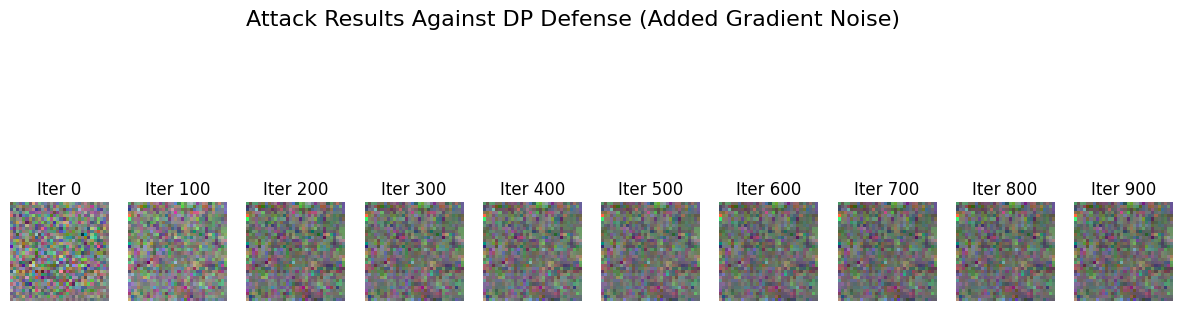

In [8]:
# Plot the progression of the attack against the noisy defense
plt.figure(figsize=(15, 5))
for i, img in enumerate(history_noisy):
    plt.subplot(1, len(history_noisy), i + 1)

    img_tensor = img[0]
    valid_img = ((img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min()))
    valid_img = valid_img.permute(1, 2, 0).numpy()

    plt.imshow(valid_img)
    plt.title(f"Iter {i * 100}")
    plt.axis('off')

plt.suptitle("Attack Results Against DP Defense (Added Gradient Noise)", fontsize=16)
plt.show()

## 5. Advanced Attack: Analytical Label Leakage
While the DLG approach uses optimization to reconstruct images, classification labels can be stolen deterministically without optimization.

**Mathematical Vulnerability:** In standard cross-entropy loss, the gradient of the bias in the final Fully Connected (FC) layer will *always* be negative for the true class, and positive for all incorrect classes. By extracting the `argmin()` of this final gradient tensor, we instantly steal the private label.

In [9]:
# --- ADVANCED IMPLEMENTATION: Analytical Label Leakage ---

print("Executing Analytical Label Leakage Attack...")

# In PyTorch, the gradients are stored in a list matching the model parameters.
# true_gradients[-1] contains the gradient of the bias in the final Linear (fc) layer.
final_layer_bias_gradients = true_gradients[-1].cpu().numpy()

# The mathematically proven vulnerability: The index with the minimum gradient value is the true label!
extracted_label = final_layer_bias_gradients.argmin()

print(f"Intercepted Bias Gradients: \n{final_layer_bias_gradients}")
print(f"--------------------------------------------------")
print(f"Ground Truth Label (Private): {target_label.item()}")
print(f"Extracted Label (Stolen):     {extracted_label}")

if target_label.item() == extracted_label:
    print("SUCCESS: Private label instantly extracted from gradients!")

Executing Analytical Label Leakage Attack...
Intercepted Bias Gradients: 
[ 0.12749033  0.05599408 -0.9113807   0.1446023   0.07915355  0.08770683
  0.12751976  0.11909508  0.06930397  0.10051487]
--------------------------------------------------
Ground Truth Label (Private): 2
Extracted Label (Stolen):     2
SUCCESS: Private label instantly extracted from gradients!


## 6. Comparative Analysis: The Impact of Batch Size
This cell evaluates how varying Federated Learning parameters affects privacy. We simulate a client computing and transmitting averaged gradients across a batch of 4 images rather than a single image. Mixing the gradients inherently obfuscates the footprint, causing the optimizer to reconstruct a superimposed "ghost" artifact rather than a distinct target.

In [10]:
import torch.optim as optim

print("Simulating FL Client with Batch Size = 4...")

# 1. Client loads a batch of 4 images instead of 1
batch_imgs = []
batch_labels = []
for i in range(42, 46): # Grab 4 consecutive images
    img, lbl = cifar_dataset[i]
    batch_imgs.append(img)
    batch_labels.append(lbl)

batch_imgs = torch.stack(batch_imgs).to(device)
batch_labels = torch.tensor(batch_labels).to(device)

# 2. Client computes averaged gradients for the batch
net.zero_grad()
batch_pred = net(batch_imgs)
batch_loss = criterion(batch_pred, batch_labels)
true_batch_gradients = torch.autograd.grad(batch_loss, net.parameters())
true_batch_gradients = [g.detach().clone() for g in true_batch_gradients]

print("Intercepted Averaged Gradients. Starting Inversion Attack...")

# 3. Attacker tries to invert the batch
dummy_batch_data = torch.rand(batch_imgs.size()).to(device).requires_grad_(True)
optimizer_batch = optim.LBFGS([dummy_batch_data], lr=0.1, max_iter=20, line_search_fn="strong_wolfe")

history_batch = []
iters_batch = 1500
tv_weight_batch = 0.00001

for i in range(iters_batch):
    def closure_batch():
        optimizer_batch.zero_grad()
        dummy_pred = net(dummy_batch_data)

        # Attacker assumes they know/stole the labels
        dummy_loss = criterion(dummy_pred, batch_labels)
        dummy_gradients = torch.autograd.grad(dummy_loss, net.parameters(), create_graph=True)

        grad_diff = 0
        for dg, tg in zip(dummy_gradients, true_batch_gradients):
            grad_diff += 1.0 - torch.nn.functional.cosine_similarity(dg.flatten(), tg.flatten(), dim=0)

        total_loss = grad_diff + tv_weight_batch * tv_loss(dummy_batch_data)
        total_loss.backward()
        return total_loss

    optimizer_batch.step(closure_batch)

    if i % 300 == 0:
        current_loss = closure_batch().item()
        print(f"Iteration {i:4d} | Loss: {current_loss:.6f}")
        history_batch.append(dummy_batch_data.clone().detach().cpu())

print("Batch attack complete!")

Simulating FL Client with Batch Size = 4...
Intercepted Averaged Gradients. Starting Inversion Attack...
Iteration    0 | Loss: 0.042703
Iteration  300 | Loss: 0.003859
Iteration  600 | Loss: 0.003734
Iteration  900 | Loss: 0.003652
Iteration 1200 | Loss: 0.003633
Batch attack complete!


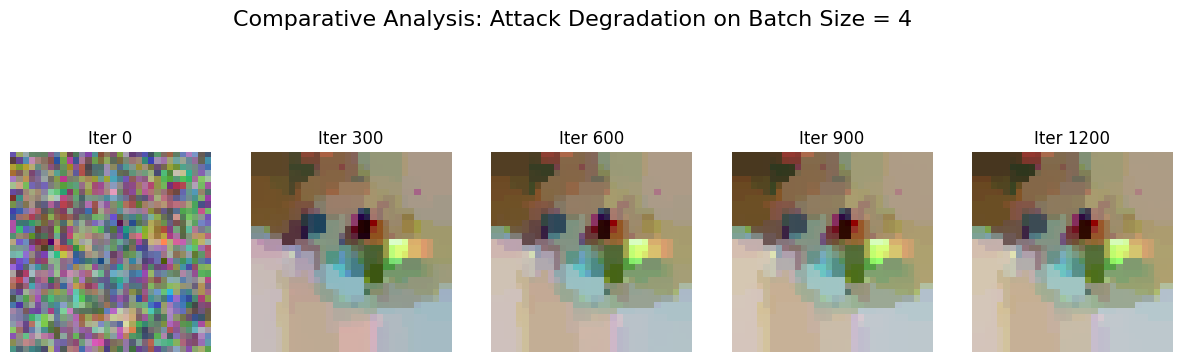

In [11]:
# Plot the results for the first image in the batch to show the degradation
plt.figure(figsize=(15, 5))
for i, batch_tensor in enumerate(history_batch):
    plt.subplot(1, len(history_batch), i + 1)

    # Just look at the first image in the reconstructed batch
    img_tensor = batch_tensor[0]
    valid_img = ((img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min()))
    valid_img = valid_img.permute(1, 2, 0).numpy()

    plt.imshow(valid_img)
    plt.title(f"Iter {i * 300}")
    plt.axis('off')

plt.suptitle("Comparative Analysis: Attack Degradation on Batch Size = 4", fontsize=16)
plt.show()

## 7. Quantitative Evaluation: Relative Data Leakage Value (RDLV)
Alongside standard metrics like Peak Signal-to-Noise Ratio (PSNR), we formalize the Relative Data Leakage Value (RDLV). This metric scales the Mean Squared Error (MSE) against the natural variance of the ground-truth image to output an intuitive percentage of data exposure (where 100% is a perfect reconstruction).

In [12]:
import torch

def calculate_rdlv(reconstructed_img, ground_truth_img):
    """
    Calculates the Relative Data Leakage Value (RDLV) as a percentage.
    It scales the Mean Squared Error against the natural variance of the image.
    100% = Perfect Leakage (identical image)
    0%   = Zero Leakage (pure noise/static)
    """
    mse = torch.nn.functional.mse_loss(reconstructed_img, ground_truth_img).item()

    # Calculate the variance of the ground truth image to understand its complexity
    image_variance = torch.var(ground_truth_img).item()

    # RDLV Formula: Maximize at 100%, penalize based on MSE relative to image variance
    rdlv = max(0.0, (1.0 - (mse / image_variance))) * 100.0

    return rdlv

# Test it on successful baseline attack using .squeeze() to match dimensions perfectly
rdlv_score = calculate_rdlv(final_reconstruction.squeeze(), target_img.squeeze())
print(f"Final Relative Data Leakage Value (RDLV): {rdlv_score:.2f}%")

Final Relative Data Leakage Value (RDLV): 93.29%
